In [5]:
###zadanie 1
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('winequality-white.csv', sep=';')

X = df.drop('quality', axis=1)

scaler = StandardScaler()
X_standaryzowane = scaler.fit_transform(X)

liczba_komponentow = X.shape[1] - 2
pca = PCA(n_components=liczba_komponentow)

X_zredukowane = pca.fit_transform(X_standaryzowane)

wyjasniona_wariancja = sum(pca.explained_variance_ratio_)

print(f"Oryginalna liczba cech: {X.shape[1]}")
print(f"Liczba składowych po redukcji PCA: {liczba_komponentow}")
print(f"Całkowita wariancja: {wyjasniona_wariancja:.4f}")

Oryginalna liczba cech: 11
Liczba składowych po redukcji PCA: 9
Całkowita wariancja: 0.9718


In [7]:
###zadanie 2
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('winequality-white.csv', sep=';')
X = df.drop('quality', axis=1)

scaler = StandardScaler()
X_standaryzowane = scaler.fit_transform(X)

pca_auto = PCA(n_components=0.95)

X_zredukowane_auto = pca_auto.fit_transform(X_standaryzowane)

liczba_zostawionych_cech = pca_auto.n_components_
wyjasniona_wariancja = sum(pca_auto.explained_variance_ratio_)

print(f"Oryginalna liczba cech: {X.shape[1]}")
print(f"Liczba cech potrzebna do zachowania minimum 95% wariancji: {liczba_zostawionych_cech}")
print(f"Faktyczna ilość zachowanej informacji: {wyjasniona_wariancja:.4f}")

Oryginalna liczba cech: 11
Liczba cech potrzebna do zachowania minimum 95% wariancji: 9
Faktyczna ilość zachowanej informacji: 0.9718


Średnia skuteczność ze wszystkich podziałów
Brak PCA wszystkie cechy: 55.31% (odchylenie: +/- 1.47%)
PCA redukcja o 2 cechy: 55.82% (odchylenie: +/- 1.49%)
PCA próg wariancji 95%: 55.82% (odchylenie: +/- 1.49%)


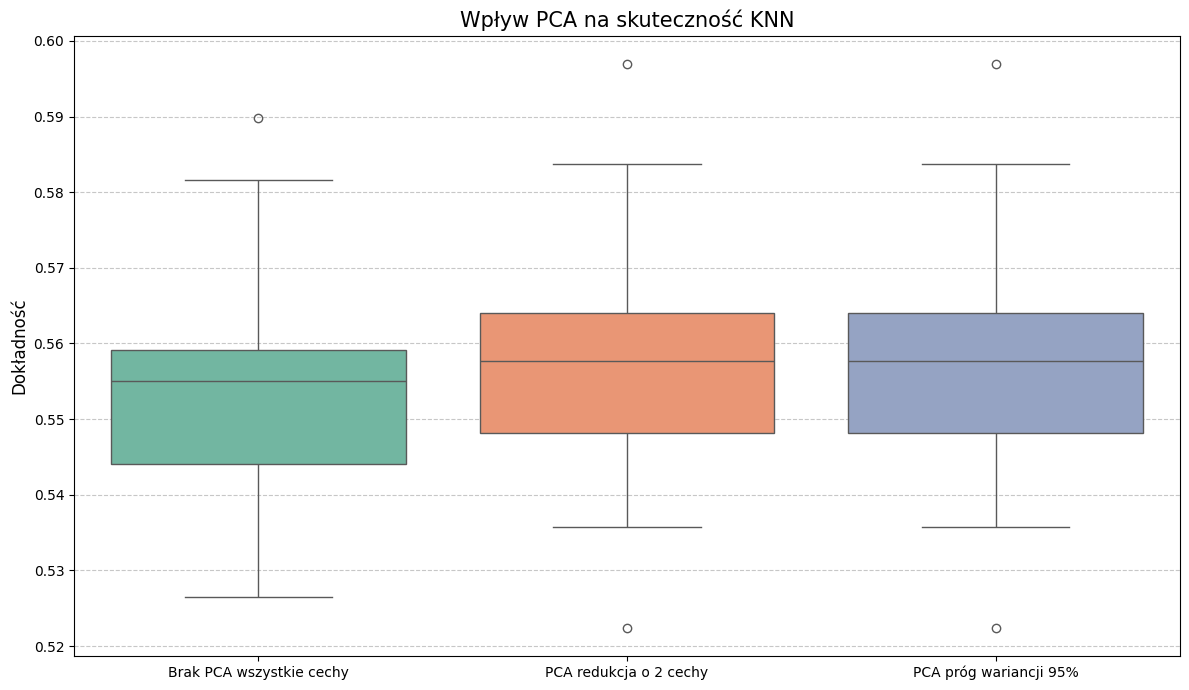

In [11]:
###zadanie 3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv('winequality-white.csv', sep=';')
X = df.drop('quality', axis=1)
y = df['quality']

liczba_eksperymentow = 30
wyniki = {
    'Brak PCA wszystkie cechy': [],
    'PCA redukcja o 2 cechy': [],
    'PCA próg wariancji 95%': []
}

for i in range(liczba_eksperymentow):

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)


    knn_1 = KNeighborsClassifier(n_neighbors=5)
    knn_1.fit(X_train_scaled, y_train)
    acc_1 = accuracy_score(y_test, knn_1.predict(X_test_scaled))
    wyniki['Brak PCA wszystkie cechy'].append(acc_1)


    pca_2 = PCA(n_components=X.shape[1] - 2)
    X_train_pca_2 = pca_2.fit_transform(X_train_scaled)
    X_test_pca_2 = pca_2.transform(X_test_scaled)

    knn_2 = KNeighborsClassifier(n_neighbors=5)
    knn_2.fit(X_train_pca_2, y_train)
    acc_2 = accuracy_score(y_test, knn_2.predict(X_test_pca_2))
    wyniki['PCA redukcja o 2 cechy'].append(acc_2)


    pca_3 = PCA(n_components=0.95)
    X_train_pca_3 = pca_3.fit_transform(X_train_scaled)
    X_test_pca_3 = pca_3.transform(X_test_scaled)

    knn_3 = KNeighborsClassifier(n_neighbors=5)
    knn_3.fit(X_train_pca_3, y_train)
    acc_3 = accuracy_score(y_test, knn_3.predict(X_test_pca_3))
    wyniki['PCA próg wariancji 95%'].append(acc_3)



df_wyniki = pd.DataFrame(wyniki)

print("Średnia skuteczność ze wszystkich podziałów")
for kolumna in df_wyniki.columns:
    srednia = df_wyniki[kolumna].mean() * 100
    odchylenie = df_wyniki[kolumna].std() * 100
    print(f"{kolumna}: {srednia:.2f}% (odchylenie: +/- {odchylenie:.2f}%)")

plt.figure(figsize=(12, 7))
sns.boxplot(data=df_wyniki, palette='Set2')

plt.title(f'Wpływ PCA na skuteczność KNN', fontsize=15)
plt.ylabel('Dokładność', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()